This tutorial is modified based on 

https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

Training on GPU
===============


Let\'s first define our device as the first visible cuda device if we
have CUDA available:


In [37]:
import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


Training a Classifier
=====================

This is it. You have seen how to define neural networks, compute loss
and make updates to the weights of the network.

Now you might be thinking,

What about data?
----------------

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a `torch.*Tensor`.

-   For images, packages such as Pillow, OpenCV are useful
-   For audio, packages such as scipy and librosa
-   For text, either raw Python or Cython based loading, or NLTK and
    SpaCy are useful

Specifically for vision, we have created a package called `torchvision`,
that has data loaders for common datasets such as ImageNet, CIFAR10,
MNIST, etc. and data transformers for images, viz.,
`torchvision.datasets` and `torch.utils.data.DataLoader`.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset. It has the classes:
'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse',
'ship', 'truck'. The images in CIFAR-10 are of size 3x32x32, i.e.
3-channel color images of 32x32 pixels in size.

![cifar10](https://pytorch.org/tutorials/_static/img/cifar10.png)

Training an image classifier
----------------------------

We will do the following steps in order:

1.  Load and normalize the CIFAR10 training and test datasets using
    `torchvision`
2.  Define a Convolutional Neural Network
3.  Define a loss function
4.  Train the network on the training data
5.  Test the network on the test data

## 1. Load and normalize CIFAR10

Using `torchvision`, it's extremely easy to load CIFAR10.


In [38]:
import torch
import torchvision
from torchvision.transforms import v2

The output of torchvision datasets are PILImage images of range \[0,
1\]. We transform them to Tensors of normalized range \[-1, 1\].


In [39]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4 # Ev

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Let us show some of the training images, for fun.


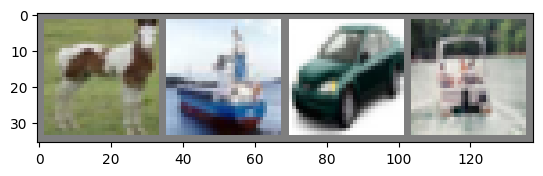

horse ship  car   ship 


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## 2. Define a Convolutional Neural Network


Neural Networks
---------------

Neural networks can be constructed using the `torch.nn` package.

 An `nn.Module` contains layers,
and a method `forward(input)` that returns the `output`.

For example, look at this network that classifies digit images:

![convnet](https://pytorch.org/tutorials/_static/img/mnist.png)

It is a simple feed-forward network. It takes the input, feeds it
through several layers one after the other, and then finally gives the
output.

A typical training procedure for a neural network is as follows:

-   Define the neural network that has some learnable parameters (or
    weights)
-   Iterate over a dataset of inputs
-   Process input through the network
-   Compute the loss (how far is the output from being correct)
-   Propagate gradients back into the network's parameters
-   Update the weights of the network, typically using a simple update
    rule: `weight = weight - learning_rate * gradient`

Define the network
------------------

Let's define this network:


In [41]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # for each 5*5 pixels in the colored image,
        # learn 6 different filters to extract features from the image
        self.conv1 = nn.Conv2d(3, 6, 5) # kernel size = 5, input channel = 3 (color), output channel = 6
        # pooling layer with kernel size = 2 and stride = 2
        self.pool = nn.MaxPool2d(2, 2)
        # kernel size = 5, input channel = 6, output channel = 16
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84) # 84 neurons in the hidden layer
        self.fc3 = nn.Linear(84, 10) # 10 output classes for CIFAR-10

    def forward(self, x):
        # Convolution layer conv1: 3 input image channel (color), 6 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a Tensor with size (N, 6, 28, 28), where N is the size of the batch
        # Subsampling layer pool: 2x2 grid, purely functional, no parameter,
        # outputs a (N, 6, 14, 14) Tensor
        x = self.pool(F.relu(self.conv1(x)))
        # Convolution layer conv2: 6 input channels, 16 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a (N, 16, 10, 10) Tensor
        # Subsampling layer pool: 2x2 grid, purely functional,
        # outputs a (N, 16, 5, 5) Tensor
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten operation: purely functional, outputs a (N, 400) Tensor, where 400=16*5*5
        x = torch.flatten(x, 1) 
        # Fully connected layer fc1: (N, 400) Tensor input,
        # and outputs a (N, 120) Tensor, it uses RELU activation function
        x = F.relu(self.fc1(x))
        # Fully connected layer fc2: (N, 120) Tensor input,
        # and outputs a (N, 84) Tensor, it uses RELU activation function
        x = F.relu(self.fc2(x))
        # Fully connected layer OUTPUT: (N, 84) Tensor input, and
        # outputs a (N, 10) Tensor
        x = self.fc3(x)
        return x


# net = Net()
# to use GPU, need to move the model to GPU before constructing the optimizer
# otherwise the optimizer will be constructed on CPU and will not work with GPU model parameters.
net = Net().to(device)

You just have to define the `forward` function, and the `backward`
function (where gradients are computed) is automatically defined for you
using `autograd`. You can use any of the Tensor operations in the
`forward` function.

The learnable parameters of a model are returned by `net.parameters()`

## 3. Define a Loss function and optimizer


Let\'s use a Classification Cross-Entropy loss and SGD with momentum.


In [42]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # this is the cross entropy loss function for multi-class classification problems
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # this is SGD (simple gradient descent) optimizer
optimizer = optim.Adam(net.parameters(), lr=1e-3) # this is another optimizer (Adam) that is more advanced than SGD, it uses adaptive learning rate and momentum to speed up convergence. It is often used in practice for training deep neural networks.

## 4. Train the network


This is when things start to get interesting. We simply have to loop
over our data iterator, and feed the inputs to the network and optimize.

Now, if you follow `loss` in the backward direction, using its
`.grad_fn` attribute, you will see a graph of computations that looks
like this:

``` {.sh}
input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d
      -> flatten -> linear -> relu -> linear -> relu -> linear
      -> Cross-Entropy loss
      -> loss
```

So, when we call `loss.backward()`, the whole graph is differentiated
w.r.t. the neural net parameters, and all Tensors in the graph that have
`requires_grad=True` will have their `.grad` Tensor accumulated with the
gradient.




In [43]:
for epoch in range(2):  # loop over the dataset multiple times
    net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        # inputs, labels = data
        # if using GPU, need to move the inputs and labels to GPU as well
        inputs, labels = data[0].to(device), data[1].to(device)
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 1.864
[1,  4000] loss: 1.581
[1,  6000] loss: 1.507
[1,  8000] loss: 1.464
[1, 10000] loss: 1.416
[1, 12000] loss: 1.362
[2,  2000] loss: 1.290
[2,  4000] loss: 1.294
[2,  6000] loss: 1.284
[2,  8000] loss: 1.273
[2, 10000] loss: 1.273
[2, 12000] loss: 1.273
Finished Training


In [44]:
# save the model weights to a file, so that we can load it later and use it for inference.
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

It's also a good practice to save the checkpoints of the model, since it's so expensive to train one. If a checkpoint is saved for future training, the `state_dict` alone isn't enough to pick up where you left off. You need to know which epoch you stopped on and some other parameters. Example code below

````python
torch.save({
    "epoch": epoch,
    "model": net.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "best_acc": best_acc,
    }, path)
````    


See [here](https://pytorch.org/docs/stable/notes/serialization.html) for
more details on saving PyTorch models.

Test the network on the test data
=================================

We have trained the network for 2 passes over the training dataset. But
we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get
familiar.


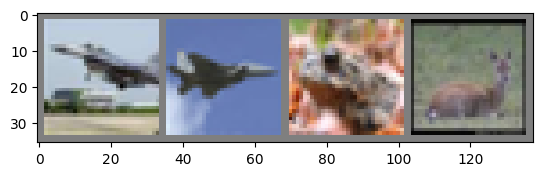

GroundTruth:  plane plane frog  deer 


In [45]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let\'s load back in our saved model (note: saving and re-loading
the model wasn\'t necessary here, we only did it to illustrate how to do
so):


In [46]:
net = Net() # rebuild the architecture of the model, otherwise the model will not be able to load the weights correctly
net.load_state_dict(torch.load(PATH, weights_only=True))
net.to(device) # move the model to GPU if available
net.eval() # set the model to evaluation mode, this is important for some layers like dropout and batchnorm that behave differently during training and evaluation

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Okay, now let us see what the neural network thinks these examples above
are:


In [47]:
# outputs = net(images)
# if using GPU, need to move the images to GPU as well
outputs = net(images.to(device))

The outputs are energies for the 10 classes. The higher the energy for a
class, the more the network thinks that the image is of the particular
class. So, let\'s get the index of the highest energy:


In [48]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  plane plane dog   frog 


The test may be too small to really learn the performance of our model. 

So, let us look at how the network performs on the whole dataset.


In [49]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad(): # no gradients needed, saves memory and time
    for data in testloader:
        # images, labels = data
        # if using GPU, need to move the images and labels to GPU as well
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 56 %


That looks way better than chance, which is 10% accuracy (randomly
picking a class out of 10 classes). Seems like the network learnt
something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:


In [50]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        # images, labels = data
        # if using GPU, need to move the images and labels to GPU as well
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 54.9 %
Accuracy for class: car   is 69.0 %
Accuracy for class: bird  is 34.8 %
Accuracy for class: cat   is 29.5 %
Accuracy for class: deer  is 62.4 %
Accuracy for class: dog   is 52.2 %
Accuracy for class: frog  is 64.6 %
Accuracy for class: horse is 61.9 %
Accuracy for class: ship  is 73.8 %
Accuracy for class: truck is 65.1 %


The results look OK, but not great. So how can we improve it? 

Change the model architecture. The model was quite simple. Maybe add more layers, or increase channels


